# Rotation $R(\theta, x_0, y_0)$
Notebook to help with deriving closed-form geometric transforms and their gradients.

In [32]:
import sympy
from sympy import Matrix, Symbol

x0 = Symbol("x_0")
y0 = Symbol("y_0")
theta = Symbol("theta")

x = Symbol("x")
y = Symbol("y")
X = Matrix([x, y, 1])

### Transformation matrix

#### Composed (passive)
We assemble the passive transform `T_old_from_new` (which expresses the points in the old frame), which corresponds to the active transform `T_old_to_new`.

We then inverse this matrix to obtain the active transform `T_new_to_old`, which transforms a point in the rotated image, to its original location in the unrotated image.

Rotation component:

In [33]:
# NOTE: negative angle, somehow sympy returns the active rotation in clockwise direction
T_oldC_to_newC = sympy.rot_axis3(-theta)  # Start with the active rotation
T_oldC_to_newC

Matrix([
[cos(theta), -sin(theta), 0],
[sin(theta),  cos(theta), 0],
[         0,           0, 1]])

In [34]:
T_oldC_from_newC = T_oldC_to_newC  # Semantics: the passive old<-new rotation is the old->new active rotation
T_newC_from_oldC = sympy.simplify(T_oldC_from_newC.T)
T_newC_from_oldC

Matrix([
[ cos(theta), sin(theta), 0],
[-sin(theta), cos(theta), 0],
[          0,          0, 1]])

In [35]:
T_newC_from_oldC @ X

Matrix([
[ x*cos(theta) + y*sin(theta)],
[-x*sin(theta) + y*cos(theta)],
[                           1]])

Offset rotation center:
- (O)riginal image coordinate frame, centered at the top-left corner, right-down orientation
- (C)entered frame at $(x_0, y_0)$, same orientation as (O)

In [36]:
T_C_from_O = Matrix([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]])
T_O_from_C = T_C_from_O.inv()

In [37]:
T_C_from_O @ X

Matrix([
[x - x_0],
[y - y_0],
[      1]])

In [38]:
T_O_from_C @ X

Matrix([
[x + x_0],
[y + y_0],
[      1]])

Complete passive transform:

In [39]:
T_newO_from_oldO = T_O_from_C @ T_newC_from_oldC @ T_C_from_O
T_newO_from_oldO

Matrix([
[ cos(theta), sin(theta), -x_0*cos(theta) + x_0 - y_0*sin(theta)],
[-sin(theta), cos(theta),  x_0*sin(theta) - y_0*cos(theta) + y_0],
[          0,          0,                                      1]])

Move to active form:

In [40]:
T_newO_to_oldO = T_newO_from_oldO
T_newO_to_oldO

Matrix([
[ cos(theta), sin(theta), -x_0*cos(theta) + x_0 - y_0*sin(theta)],
[-sin(theta), cos(theta),  x_0*sin(theta) - y_0*cos(theta) + y_0],
[          0,          0,                                      1]])

Apply transformation to some pixel $(x,y)$:

In [41]:
X_new = Matrix([x, y, 1])
X_old_hom = T_newO_to_oldO @ X  # Homogeneous coordinates
X_old = Matrix([X_old_hom[0], X_old_hom[1]])
X_old

Matrix([
[ x*cos(theta) - x_0*cos(theta) + x_0 + y*sin(theta) - y_0*sin(theta)],
[-x*sin(theta) + x_0*sin(theta) + y*cos(theta) - y_0*cos(theta) + y_0]])

### Gradient

In [42]:
grad = sympy.Derivative(X_old, theta, evaluate=True)
grad

Matrix([
[-x*sin(theta) + x_0*sin(theta) + y*cos(theta) - y_0*cos(theta)],
[-x*cos(theta) + x_0*cos(theta) - y*sin(theta) + y_0*sin(theta)]])

In [46]:
sympy.simplify(grad[0] ** 2 + grad[1] ** 2)

x**2 - 2*x*x_0 + x_0**2 + y**2 - 2*y*y_0 + y_0**2

Trying to understand the candidate locations for the maximum gradient:

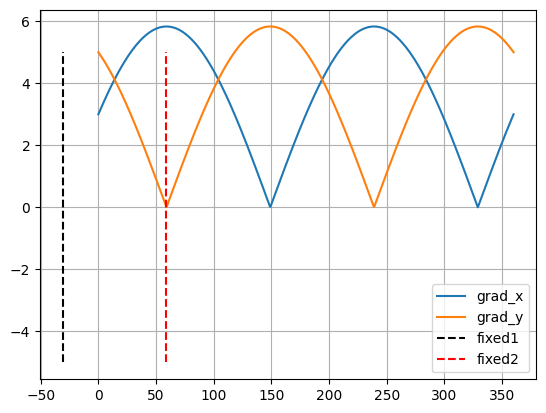

In [62]:
import matplotlib.pyplot as plt
import numpy as np

x0 = 14
y0 = 14
x = 9
y = 17

theta_deg = np.linspace(0, 360, 1000)
theta_rad = np.deg2rad(theta_deg)
grad_x = np.array(-(x - x0) * np.sin(theta_rad) + (y - y0) * np.cos(theta_rad))
grad_y = np.array(-(x - x0) * np.cos(theta_rad) - (y - y0) * np.sin(theta_rad))

plt.figure()
plt.plot(theta_deg, np.abs(grad_x), label="grad_x")
plt.plot(theta_deg, np.abs(grad_y), label="grad_y")
# plt.plot(theta_deg, np.abs(grad_x) + np.abs(grad_y), label="sum abs")
# plt.plot(theta_deg, np.abs(grad_x) * np.abs(grad_y), label="prod abs")
# plt.plot(theta_deg, np.sqrt(grad_x**2 + grad_y**2), label="norm")
fixed1_rad = np.arctan((y - y0) / (x - x0))
fixed2_rad = np.arctan(-(x - x0) / (y - y0))
fixed1_deg = np.rad2deg(fixed1_rad)
fixed2_deg = np.rad2deg(fixed2_rad)
plt.plot([fixed1_deg, fixed1_deg], [-5, 5], "--k", label="fixed1")
plt.plot([fixed2_deg, fixed2_deg], [-5, 5], "--r", label="fixed2")
plt.grid()
plt.legend()
plt.show()